# Uber-Ride-Analysis

## Uber Data Cleaning & Preparation

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

### Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\hp\Downloads\Uber_Project\ncr_ride_bookings.csv")

### Initial Data Inspection

In [3]:
df.shape

(150000, 21)

In [4]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [6]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


In [7]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### Duplicate Booking IDs

In [9]:
df["Booking ID"].duplicated().sum()

np.int64(1233)

In [10]:
duplicate_bookings = df[df["Booking ID"].duplicated(keep=False)]

In [11]:
duplicate_bookings.sort_values("Booking ID").head(10)

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
81334,15-10-2024,18:17:23,"""CNR1026036""",Completed,"""CID6480133""",Go Mini,Khandsa,Ashok Vihar,3.8,43.3,...,NaN,NaN,NaN,NaN,NaN,102.0,36.51,4.9,4.2,UPI
9192,21-07-2024,17:59:41,"""CNR1026036""",No Driver Found,"""CID6974869""",Go Mini,Seelampur,Nehru Place,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9587,17-12-2024,19:19:02,"""CNR1029172""",Completed,"""CID6382731""",Auto,Inderlok,Laxmi Nagar,6.9,34.4,...,NaN,NaN,NaN,NaN,NaN,332.0,36.38,4.3,4.3,UPI
1353,19-01-2024,17:00:57,"""CNR1029172""",Incomplete,"""CID2615731""",Bike,Jhilmil,Narsinghpur,4.7,26.7,...,NaN,NaN,NaN,1.0,Customer Demand,429.0,16.16,NaN,NaN,UPI
82029,05-11-2024,16:50:20,"""CNR1051228""",Completed,"""CID3177617""",Auto,Dwarka Sector 21,Nehru Place,8.5,24.8,...,NaN,NaN,NaN,NaN,NaN,246.0,4.80,4.6,4.5,UPI
110412,31-01-2024,08:42:04,"""CNR1051228""",Completed,"""CID5242056""",Premier Sedan,Arjangarh,Yamuna Bank,14.2,25.4,...,NaN,NaN,NaN,NaN,NaN,930.0,13.06,3.4,4.2,Cash
87333,20-04-2024,23:16:21,"""CNR1056023""",Completed,"""CID9367665""",Premier Sedan,Badshahpur,Sultanpur,7.1,25.7,...,NaN,NaN,NaN,NaN,NaN,116.0,46.54,3.8,5.0,Credit Card
120008,07-07-2024,17:18:49,"""CNR1056023""",Incomplete,"""CID4890470""",Go Sedan,Meerut,Tilak Nagar,6.6,24.2,...,NaN,NaN,NaN,1.0,Customer Demand,420.0,5.13,NaN,NaN,Uber Wallet
71570,12-02-2024,19:02:47,"""CNR1058956""",Cancelled by Customer,"""CID2451799""",Premier Sedan,Patel Chowk,Kaushambi,19.9,NaN,...,Wrong Address,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38548,15-10-2024,13:33:55,"""CNR1058956""",Completed,"""CID1882606""",Go Mini,Badshahpur,MG Road,3.7,20.2,...,NaN,NaN,NaN,NaN,NaN,194.0,24.65,4.3,4.3,Cash


### Categorical Distribution

In [12]:
df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [13]:
df["Vehicle Type"].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

In [14]:
df["Payment Method"].value_counts()

Payment Method
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64

### Missing Values

In [15]:
missing_by_status = df.groupby("Booking Status").agg(
    lambda x: x.isnull().sum()
)

missing_by_status

,Date,Time,Booking ID,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
Booking Status,,,,,,,,,,,,,,,,,,,,
Cancelled by Customer,0,0,0,0,0,0,0,0,10500,0,0,10500,10500,10500,10500,10500,10500,10500,10500,10500
Cancelled by Driver,0,0,0,0,0,0,0,0,27000,27000,27000,0,0,27000,27000,27000,27000,27000,27000,27000
Completed,0,0,0,0,0,0,0,0,0,93000,93000,93000,93000,93000,93000,0,0,0,0,0
Incomplete,0,0,0,0,0,0,0,0,0,9000,9000,9000,9000,0,0,0,0,9000,9000,0
No Driver Found,0,0,0,0,0,0,0,10500,10500,10500,10500,10500,10500,10500,10500,10500,10500,10500,10500,10500


In [16]:
df[df["Avg VTAT"].isnull()]["Booking Status"].value_counts()

Booking Status
No Driver Found    10500
Name: count, dtype: int64

In [17]:
df[df["Avg CTAT"].isnull()]["Booking Status"].value_counts()

Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Name: count, dtype: int64

In [18]:
df[df["Booking Value"].isnull()]["Booking Status"].value_counts()

Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Name: count, dtype: int64

In [19]:
df[df["Ride Distance"].isnull()]["Booking Status"].value_counts()

Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Name: count, dtype: int64

In [20]:
df[df["Driver Ratings"].isnull()]["Booking Status"].value_counts()

Booking Status
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

### Date & Time Conversion

In [21]:
df["Date"].head()

0    23-03-2024
1    29-11-2024
2    23-08-2024
3    21-10-2024
4    16-09-2024
Name: Date, dtype: object

In [22]:
df["Date"].unique()[:10]

array(['23-03-2024', '29-11-2024', '23-08-2024', '21-10-2024',
       '16-09-2024', '06-02-2024', '17-06-2024', '19-03-2024',
       '14-09-2024', '16-12-2024'], dtype=object)

In [23]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

In [24]:
df["Date"].dtype

dtype('<M8[ns]')

In [25]:
df["Time"].head()

0    12:29:38
1    18:01:39
2    08:56:10
3    17:17:25
4    22:08:00
Name: Time, dtype: object

In [26]:
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.time

In [27]:
df["Time"].dtype

dtype('O')

### Numerical Distribution 

In [28]:
numerical_columns = df.select_dtypes(include=["number"]).columns

numerical_columns

Index(['Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer',
       'Cancelled Rides by Driver', 'Incomplete Rides', 'Booking Value',
       'Ride Distance', 'Driver Ratings', 'Customer Rating'],
      dtype='object')

In [29]:
df[numerical_columns].agg(["min", "max"])

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
min,2.0,10.0,1.0,1.0,1.0,50.0,1.0,3.0,3.0
max,20.0,45.0,1.0,1.0,1.0,4277.0,50.0,5.0,5.0


### Date & Time Attributes

In [31]:
df["Month"] = df["Date"].dt.month_name()

In [32]:
df[["Date", "Month"]].head()

,Date,Month
0,2024-03-23,March
1,2024-11-29,November
2,2024-08-23,August
3,2024-10-21,October
4,2024-09-16,September


In [33]:
df["Day Name"] = df["Date"].dt.day_name()

In [34]:
df[["Date", "Day Name"]].head()

,Date,Day Name
0,2024-03-23,Saturday
1,2024-11-29,Friday
2,2024-08-23,Friday
3,2024-10-21,Monday
4,2024-09-16,Monday


In [35]:
df["Hour"] = pd.to_datetime(
    df["Time"].astype(str),
    format="%H:%M:%S"
).dt.hour

In [36]:
df[["Time", "Hour"]].head()

,Time,Hour
0,12:29:38,12
1,18:01:39,18
2,08:56:10,8
3,17:17:25,17
4,22:08:00,22


In [37]:
def get_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Time Period"] = df["Hour"].apply(get_time_period)

In [38]:
df[["Time", "Hour", "Time Period"]].head(10)

,Time,Hour,Time Period
0,12:29:38,12,Afternoon
1,18:01:39,18,Evening
2,08:56:10,8,Morning
3,17:17:25,17,Evening
4,22:08:00,22,Night
5,09:44:56,9,Morning
6,15:45:58,15,Afternoon
7,17:37:37,17,Evening
8,12:49:09,12,Afternoon
9,19:06:48,19,Evening


## Final Data Review

In [40]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns)

Shape: (150000, 25)

Data Types:
Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratings                 

# Exploratory Data Analysis 

# 🚗 Overall Booking Overview

### Total Bookings

In [41]:
total_bookings = len(df)

print("Total Bookings:", total_bookings)

Total Bookings: 150000


### Booking Status Distribution

In [42]:
df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

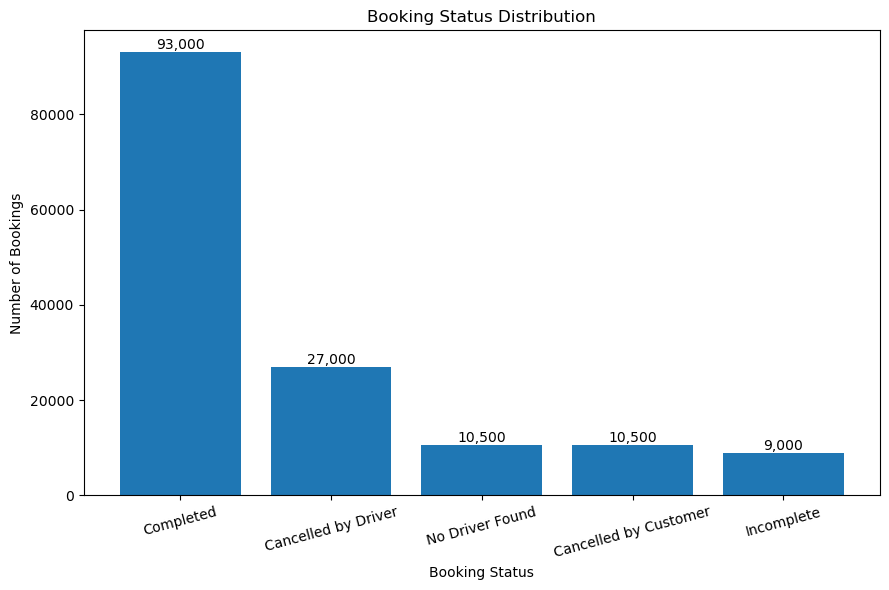

In [43]:
import matplotlib.pyplot as plt

# Count booking statuses
booking_status = df["Booking Status"].value_counts()

# Create chart
plt.figure(figsize=(9, 6))

bars = plt.bar(
    booking_status.index,
    booking_status.values
)

# Add numbers on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

# Chart title and labels
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Bookings")

# Rotate labels slightly
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [44]:
(df["Booking Status"].value_counts(normalize=True) * 100).round(2)

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64

In [45]:
completed = (df["Booking Status"] == "Completed").sum()

unsuccessful = total_bookings - completed

print("Completed:", completed)
print("Unsuccessful:", unsuccessful)

Completed: 93000
Unsuccessful: 57000


In [46]:
completed_rate = (completed / total_bookings) * 100
unsuccessful_rate = (unsuccessful / total_bookings) * 100

print("Completion Rate:", completed_rate, "%")
print("Unsuccessful Rate:", unsuccessful_rate, "%")

Completion Rate: 62.0 %
Unsuccessful Rate: 38.0 %


## Booking Status & Cancellation Analysis

In [47]:
df["Reason for cancelling by Customer"].value_counts()

Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64

In [48]:
df["Driver Cancellation Reason"].value_counts()

Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64

In [49]:
df["Incomplete Rides Reason"].value_counts()

Incomplete Rides Reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948
Name: count, dtype: int64

## Vehicle Type Analysis 🚗

In [50]:
df["Vehicle Type"].value_counts()

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

In [51]:
## Vehicle Type vs Booking Status

In [52]:
pd.crosstab(
    df["Vehicle Type"],
    df["Booking Status"]
)

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Vehicle Type,,,,,
Auto,2680,6643,23155,2260,2681
Bike,1575,4077,14034,1328,1503
Go Mini,2097,5330,18549,1815,2015
Go Sedan,1832,5031,16676,1642,1960
Premier Sedan,1266,3250,11252,1063,1280
Uber XL,327,762,2783,262,315
eBike,723,1907,6551,630,746


In [53]:
vehicle_status_pct = pd.crosstab(
    df["Vehicle Type"],
    df["Booking Status"],
    normalize="index"
) * 100

vehicle_status_pct.round(2)

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found
Vehicle Type,,,,,
Auto,7.16,17.75,61.88,6.04,7.16
Bike,6.99,18.11,62.33,5.90,6.67
Go Mini,7.04,17.88,62.23,6.09,6.76
Go Sedan,6.75,18.54,61.44,6.05,7.22
Premier Sedan,6.99,17.94,62.13,5.87,7.07
Uber XL,7.35,17.13,62.55,5.89,7.08
eBike,6.85,18.06,62.05,5.97,7.07


In [54]:
df.groupby("Vehicle Type")["Booking Value"].agg(["count", "mean", "sum"]).round(2)

,count,mean,sum
Vehicle Type,,,
Auto,25415,506.73,12878422.0
Bike,15362,510.20,7837697.0
Go Mini,20364,507.68,10338496.0
Go Sedan,18318,511.50,9369719.0
Premier Sedan,12315,509.57,6275332.0
Uber XL,3045,501.82,1528032.0
eBike,7181,503.90,3618485.0


## Time-Based Analysis ⏰

### Bookings by Month

In [55]:
monthly_bookings = df["Month"].value_counts()

monthly_bookings

Month
July         12897
January      12861
May          12778
March        12719
October      12651
August       12636
June         12440
November     12394
December     12250
September    12248
April        12199
February     11927
Name: count, dtype: int64

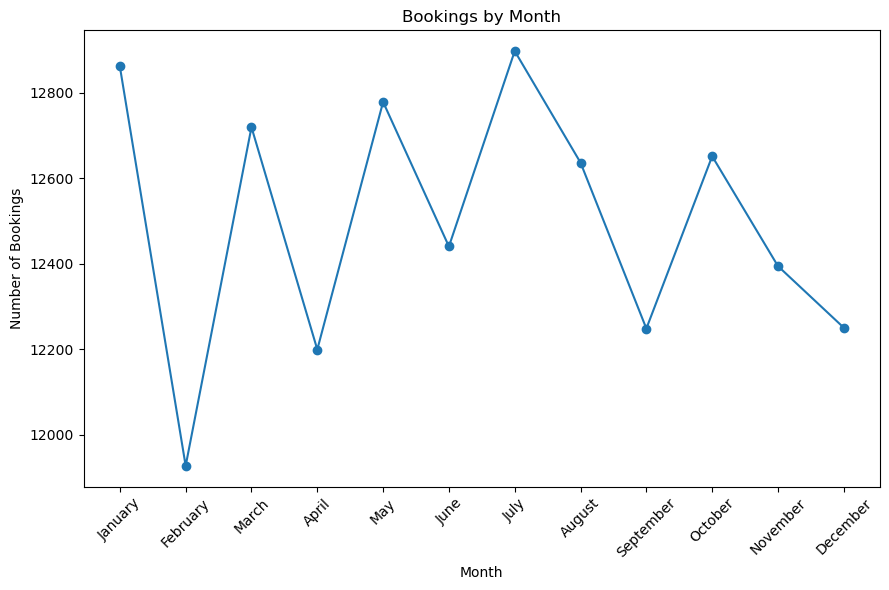

In [56]:
import matplotlib.pyplot as plt

# Correct calendar order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

# Count and arrange bookings
monthly_bookings = (
    df["Month"]
    .value_counts()
    .reindex(month_order)
)

# Line chart
plt.figure(figsize=(9, 6))

plt.plot(
    monthly_bookings.index,
    monthly_bookings.values,
    marker="o"
)

plt.title("Bookings by Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
df["Day Name"].value_counts()

Day Name
Monday       21644
Saturday     21542
Wednesday    21413
Sunday       21398
Friday       21397
Tuesday      21391
Thursday     21215
Name: count, dtype: int64

In [58]:
df["Hour"].value_counts().sort_index()

Hour
0      1373
1      1360
2      1339
3      1383
4      1321
5      2786
6      4160
7      5450
8      6861
9      8234
10     9577
11     8390
12     7006
13     5470
14     7031
15     8202
16     9633
17    11044
18    12397
19    11047
20     9630
21     8103
22     5441
23     2762
Name: count, dtype: int64

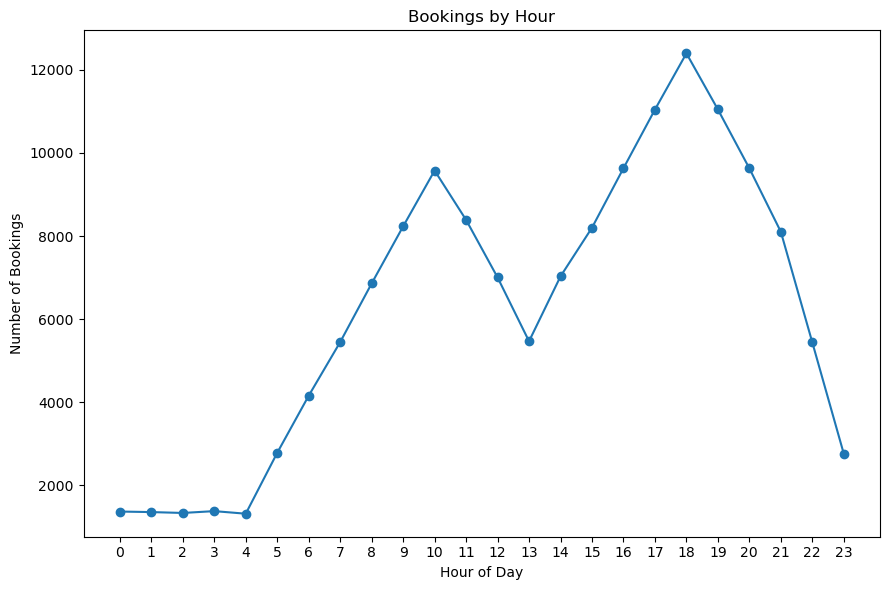

In [59]:
hourly_bookings = (
    df["Hour"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 6))

plt.plot(
    hourly_bookings.index,
    hourly_bookings.values,
    marker="o"
)

plt.title("Bookings by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Bookings")

plt.xticks(range(24))
plt.tight_layout()
plt.show()

In [60]:
df["Time Period"].value_counts()

Time Period
Morning      45458
Evening      44118
Afternoon    37342
Night        23082
Name: count, dtype: int64

## Revenue / Booking Value Analysis 💰

### Total Booking Value

In [61]:
df["Booking Value"].sum()

np.float64(51846183.0)

### Average Booking Value

In [62]:
df["Booking Value"].mean()

np.float64(508.29591176470586)

### 📅 Booking Value by Month

In [63]:
df.groupby("Month")["Booking Value"].sum()

Month
April        4253789.0
August       4243509.0
December     4319618.0
February     4085790.0
January      4411069.0
July         4365923.0
June         4325660.0
March        4568188.0
May          4320679.0
November     4343395.0
October      4417170.0
September    4191393.0
Name: Booking Value, dtype: float64

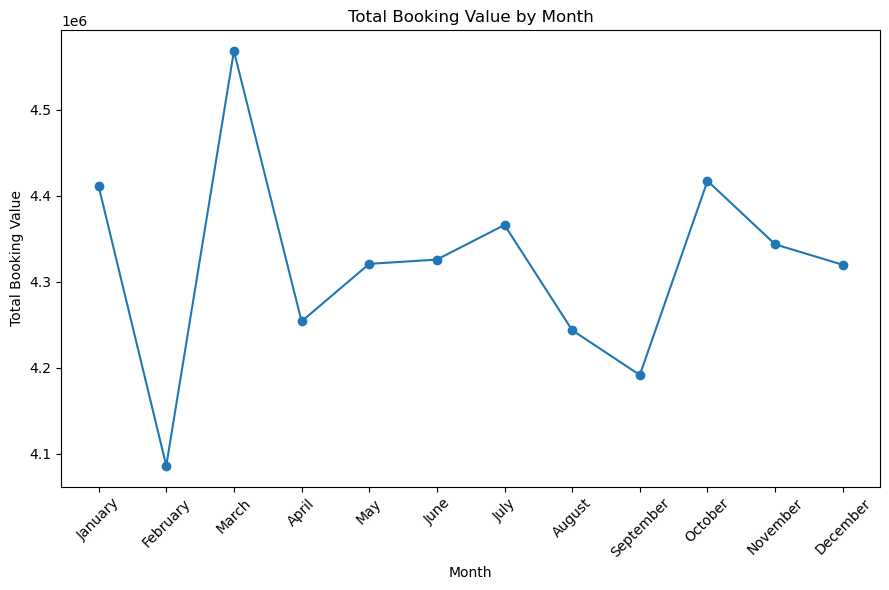

In [64]:
monthly_value = (
    df.groupby("Month")["Booking Value"]
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(9, 6))

plt.plot(
    monthly_value.index,
    monthly_value.values,
    marker="o"
)

plt.title("Total Booking Value by Month")
plt.xlabel("Month")
plt.ylabel("Total Booking Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Ratings Analysis ⭐

### Average Driver  And Customer Rating

In [65]:
df[["Driver Ratings", "Customer Rating"]].mean()

Driver Ratings     4.230992
Customer Rating    4.404584
dtype: float64

### Ratings by Vehicle Type 🚗

In [66]:
df.groupby("Vehicle Type")[
    ["Driver Ratings", "Customer Rating"]
].mean().round(2)

,Driver Ratings,Customer Rating
Vehicle Type,,
Auto,4.23,4.40
Bike,4.23,4.40
Go Mini,4.23,4.40
Go Sedan,4.23,4.41
Premier Sedan,4.23,4.40
Uber XL,4.24,4.40
eBike,4.23,4.40


## Export Cleaned Dataset

In [67]:
df.to_csv("uber_cleaned.csv", index=False)

In [68]:
!pip install sqlalchemy pymysql

In [69]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus

In [70]:
username = "root"
password = quote_plus("YOUR_PASSWORD"")
host = "localhost"
database = "uber_analysis"

In [71]:
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}/{database}"
)

In [72]:
df.to_sql(
    name="uber_rides",
    con=engine,
    if_exists="replace",
    index=False
)

150000

In [73]:
print("Data uploaded successfully!")

Data uploaded successfully!
